In [1]:

!pip install pandas numpy matplotlib seaborn scikit-learn -q


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_auc_score, roc_curve)
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')
print("All libraries loaded!")

All libraries loaded!


In [2]:
url = "https://raw.githubusercontent.com/SIAM0808/Artificial_Intelligence_and_Machine_Learning_Lab/main/DT/dataset/Titanic-Dataset.csv"
df = pd.read_csv(url)

print("Dataset loaded! Shape:", df.shape)
df.head()


Dataset loaded! Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Data Preprocessing

In [3]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
target = 'Survived'

df_clean = df[features + [target]].copy()

# Handle missing values
df_clean['Age'].fillna(df_clean['Age'].median(), inplace=True)
df_clean['Fare'].fillna(df_clean['Fare'].median(), inplace=True)
df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0], inplace=True)

# Encode categorical columns
le_sex = LabelEncoder()
df_clean['Sex'] = le_sex.fit_transform(df_clean['Sex'])

le_emb = LabelEncoder()
df_clean['Embarked'] = le_emb.fit_transform(df_clean['Embarked'])

print("Missing values after cleaning:", df_clean.isnull().sum().sum())

X = df_clean[features]
y = df_clean[target]

# Split: 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train_sc.shape[0]} | Val: {X_val_sc.shape[0]} | Test: {X_test_sc.shape[0]}")

Missing values after cleaning: 0
Train: 623 | Val: 134 | Test: 134


# Train CART Model (Gini)

In [4]:
cart_params = {
    'max_depth': [2, 3, 4, 5, 6, 8, 10, None],
    'min_samples_split': [2, 5, 10, 20]
}

cart_base = DecisionTreeClassifier(criterion='gini', random_state=42)
cart_gs = GridSearchCV(cart_base, cart_params, cv=5, scoring='accuracy', n_jobs=-1)
cart_gs.fit(X_train_sc, y_train)

best_cart = cart_gs.best_estimator_
print("CART Best Parameters:", cart_gs.best_params_)
print(f"CART CV Accuracy: {cart_gs.best_score_:.4f}")
print(f"CART Test Accuracy: {accuracy_score(y_test, best_cart.predict(X_test_sc)):.4f}")

CART Best Parameters: {'max_depth': 4, 'min_samples_split': 2}
CART CV Accuracy: 0.8202
CART Test Accuracy: 0.7612


# Train ID3 Model (Entropy)

In [5]:
id3_params = {
    'max_depth': [2, 3, 4, 5, 6, 8, 10, None],
    'min_samples_split': [2, 5, 10, 20]
}

id3_base = DecisionTreeClassifier(criterion='entropy', random_state=42)
id3_gs = GridSearchCV(id3_base, id3_params, cv=5, scoring='accuracy', n_jobs=-1)
id3_gs.fit(X_train_sc, y_train)

best_id3 = id3_gs.best_estimator_
print("ID3 Best Parameters:", id3_gs.best_params_)
print(f"ID3 CV Accuracy: {id3_gs.best_score_:.4f}")
print(f"ID3 Test Accuracy: {accuracy_score(y_test, best_id3.predict(X_test_sc)):.4f}")

ID3 Best Parameters: {'max_depth': 6, 'min_samples_split': 20}
ID3 CV Accuracy: 0.8250
ID3 Test Accuracy: 0.7612


# Plot 1: Decision Boundary (2x1)

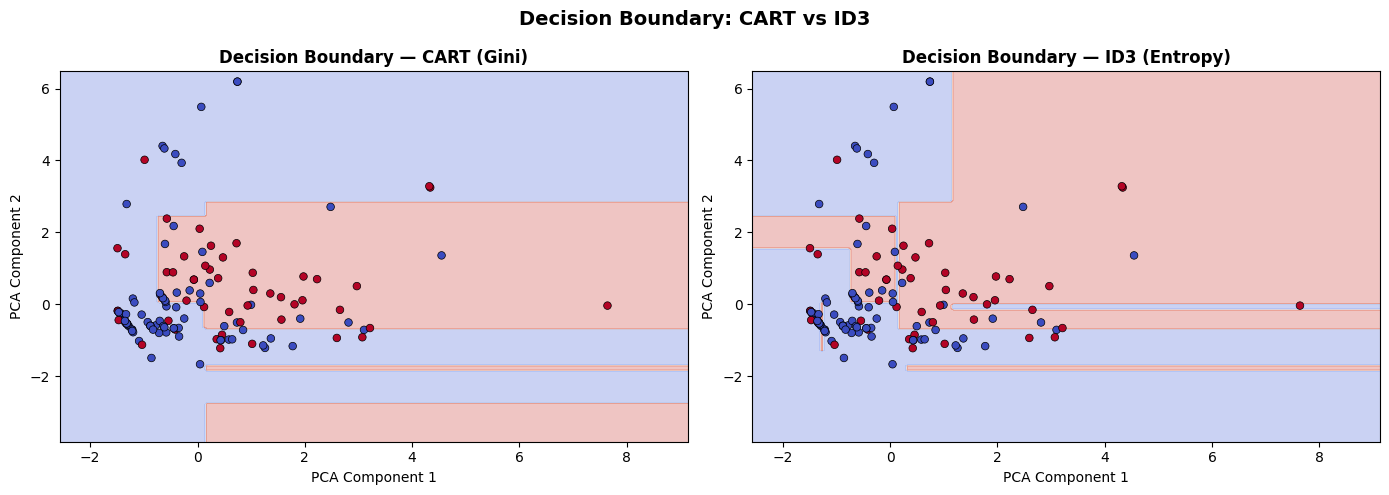

Saved: decision_boundary.png


In [6]:
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train_sc)
X_test_2d  = pca.transform(X_test_sc)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
models = [('CART (Gini)', best_cart, 'gini'), ('ID3 (Entropy)', best_id3, 'entropy')]

for ax, (name, model, crit) in zip(axes, models):
    clf2 = DecisionTreeClassifier(
        criterion=crit,
        max_depth=model.max_depth,
        min_samples_split=model.min_samples_split,
        random_state=42)
    clf2.fit(X_train_2d, y_train)

    h = 0.05
    x_min, x_max = X_train_2d[:,0].min()-1, X_train_2d[:,0].max()+1
    y_min, y_max = X_train_2d[:,1].min()-1, X_train_2d[:,1].max()+1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                          np.arange(y_min, y_max, h))
    Z = clf2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X_test_2d[:,0], X_test_2d[:,1],
               c=y_test, cmap='coolwarm', edgecolors='k', s=30, linewidth=0.5)
    ax.set_title(f'Decision Boundary — {name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('PCA Component 1')
    ax.set_ylabel('PCA Component 2')

plt.suptitle('Decision Boundary: CART vs ID3', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('decision_boundary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: decision_boundary.png")

# Plot 2: Confusion Matrix (2x1)

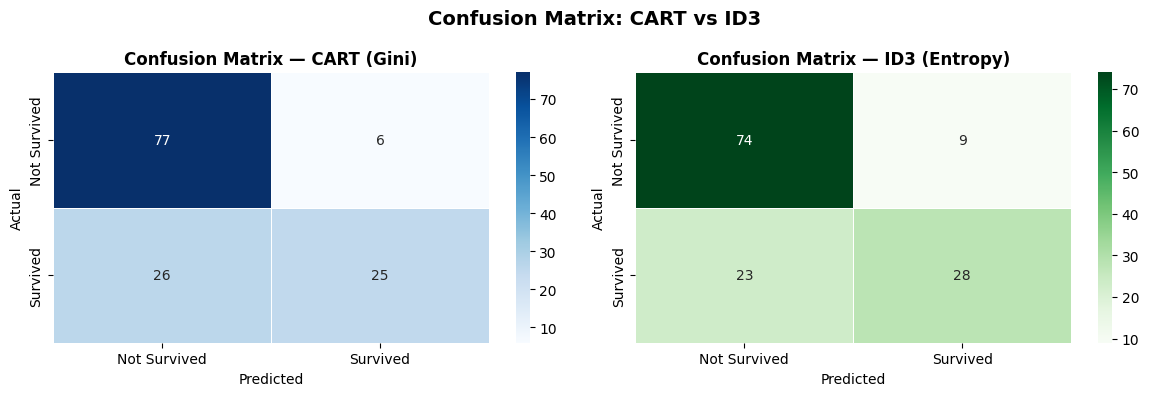

Saved: confusion_matrix.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
models = [('CART (Gini)', best_cart, 'Blues'), ('ID3 (Entropy)', best_id3, 'Greens')]

for ax, (name, model, cmap) in zip(axes, models):
    y_pred = model.predict(X_test_sc)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Not Survived','Survived'],
                yticklabels=['Not Survived','Survived'],
                linewidths=0.5)
    ax.set_title(f'Confusion Matrix — {name}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrix: CART vs ID3', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix.png")

# Plot 3: ROC Curve (2x1)

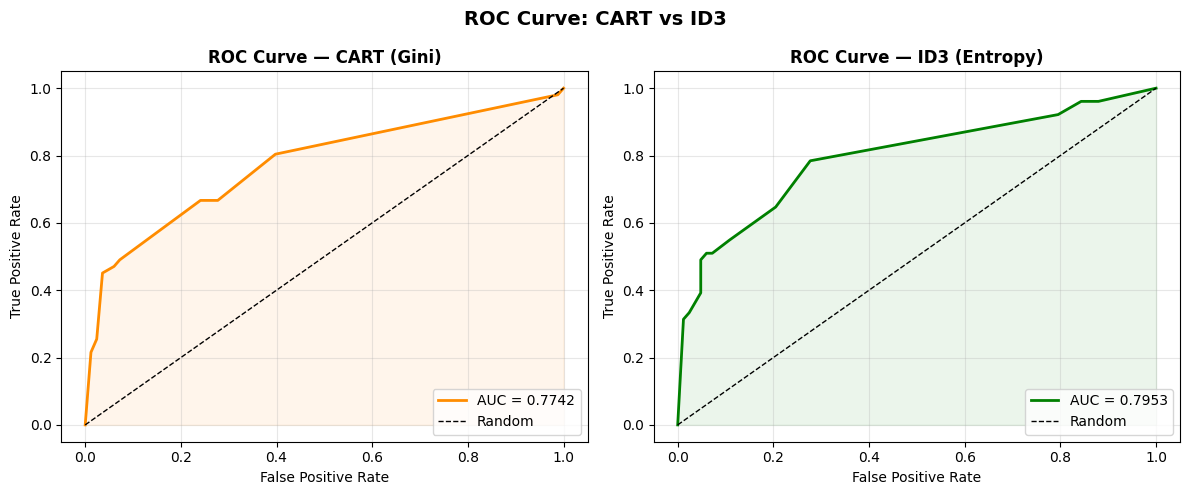

Saved: roc_curve.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
models = [('CART (Gini)', best_cart, 'darkorange'), ('ID3 (Entropy)', best_id3, 'green')]

for ax, (name, model, color) in zip(axes, models):
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'AUC = {auc:.4f}')
    ax.plot([0,1],[0,1],'k--', lw=1, label='Random')
    ax.fill_between(fpr, tpr, alpha=0.08, color=color)
    ax.set_title(f'ROC Curve — {name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

plt.suptitle('ROC Curve: CART vs ID3', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: roc_curve.png")

# Plot 4: Metrics Bar Chart (combined)

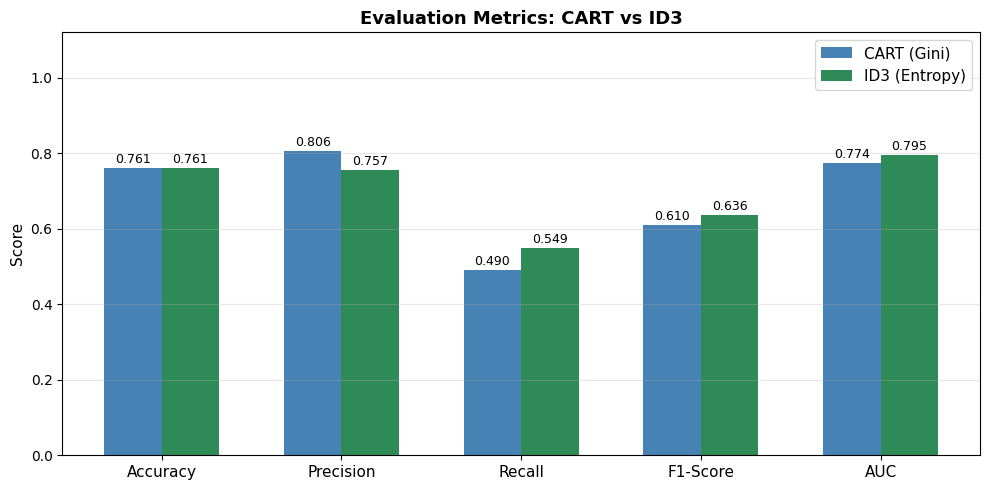

Saved: metrics_comparison.png


In [9]:
def get_metrics(model, X, y):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]
    return {
        'Accuracy' : accuracy_score(y, y_pred),
        'Precision': precision_score(y, y_pred),
        'Recall'   : recall_score(y, y_pred),
        'F1-Score' : f1_score(y, y_pred),
        'AUC'      : roc_auc_score(y, y_prob)
    }

cart_metrics = get_metrics(best_cart, X_test_sc, y_test)
id3_metrics  = get_metrics(best_id3,  X_test_sc, y_test)

metric_names = list(cart_metrics.keys())
cart_vals = list(cart_metrics.values())
id3_vals  = list(id3_metrics.values())

x = np.arange(len(metric_names))
width = 0.32

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, cart_vals, width, label='CART (Gini)', color='steelblue')
bars2 = ax.bar(x + width/2, id3_vals,  width, label='ID3 (Entropy)', color='seagreen')

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Evaluation Metrics: CART vs ID3', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: metrics_comparison.png")

# Plot 5: Tree Structure

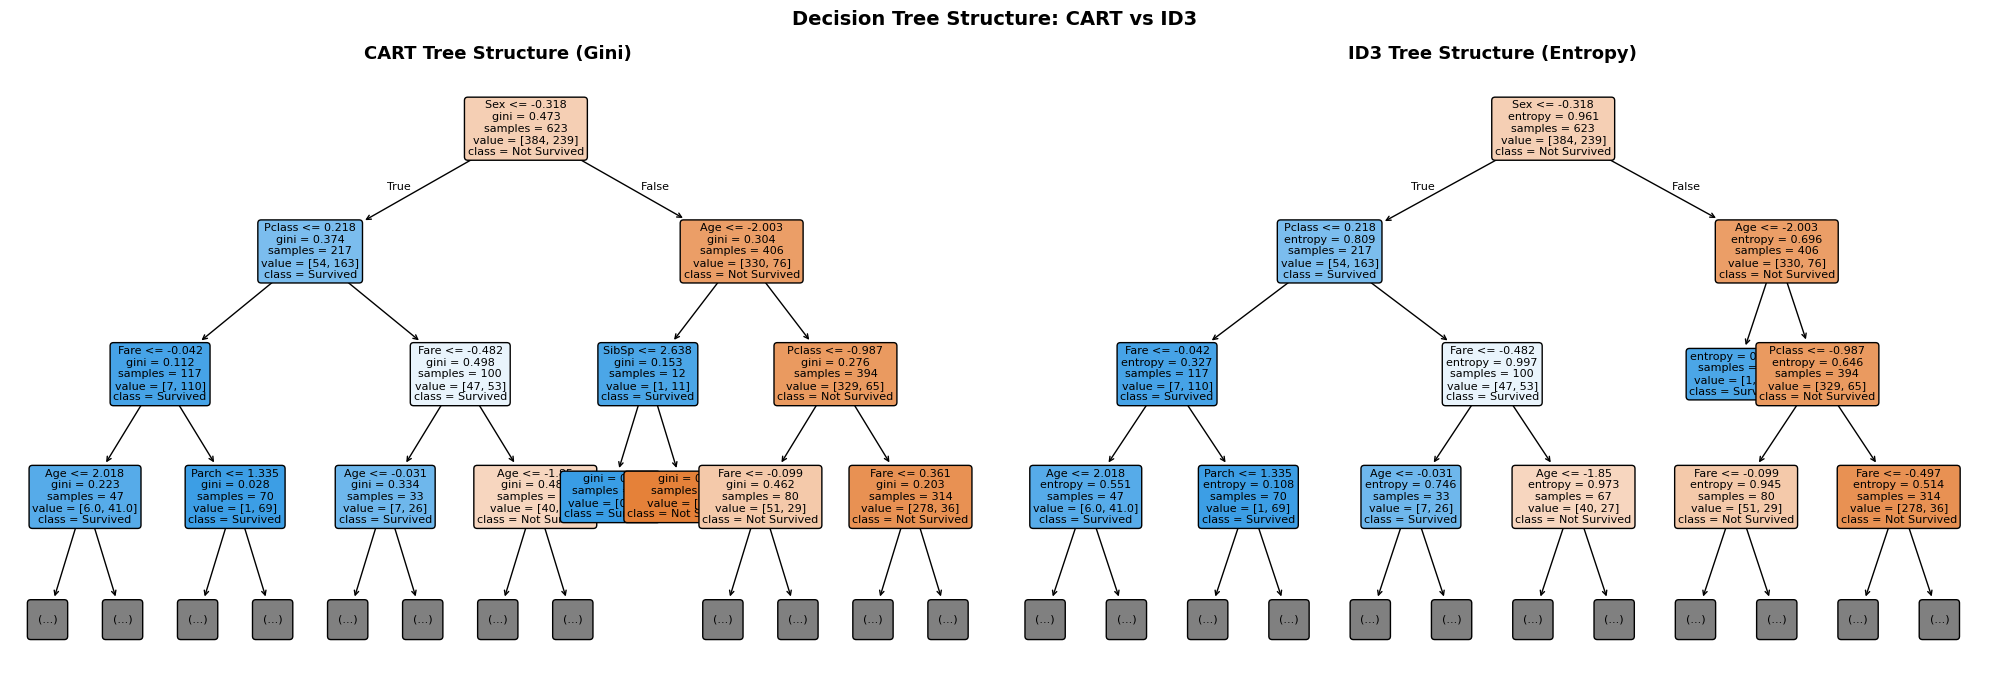

Saved: tree_structure.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

plot_tree(best_cart, ax=axes[0], filled=True, rounded=True,
          feature_names=features, class_names=['Not Survived','Survived'],
          max_depth=3, fontsize=8)
axes[0].set_title('CART Tree Structure (Gini)', fontsize=13, fontweight='bold')

plot_tree(best_id3, ax=axes[1], filled=True, rounded=True,
          feature_names=features, class_names=['Not Survived','Survived'],
          max_depth=3, fontsize=8)
axes[1].set_title('ID3 Tree Structure (Entropy)', fontsize=13, fontweight='bold')

plt.suptitle('Decision Tree Structure: CART vs ID3', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('tree_structure.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: tree_structure.png")